# Task 3 by Jan Bergmeier

Import needed libraries:

In [177]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

Read csv file and look at its contents:

In [178]:
df = pd.read_csv("../Wine_Test_01.csv")
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,0
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,0
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,1
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,1
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,1
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,0
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,1


## Task 3 a)

Scale original dataset:

In [179]:
scaler = StandardScaler()

y = df["quality"]
X = df.drop(columns=["quality"])
X = scaler.fit_transform(df)
X

array([[-0.52157961,  0.93933222, -1.36502663, ..., -0.57365783,
        -0.96338181, -1.09071315],
       [-0.29259344,  1.94181282, -1.36502663, ...,  0.1308811 ,
        -0.59360107, -1.09071315],
       [-0.29259344,  1.27349242, -1.16156762, ..., -0.04525363,
        -0.59360107, -1.09071315],
       ...,
       [-1.20853813,  0.38239855, -0.9581086 , ..., -0.45623467,
         0.05351522, -1.09071315],
       [-1.38027776,  0.10393172, -0.8563791 , ...,  0.60057372,
         0.70063152,  0.91683134],
       [-1.38027776,  0.6330187 , -0.75464959, ...,  0.30701583,
        -0.22382033, -1.09071315]], shape=(1143, 12))

Perform PCA on the same number of components as attributes and get cumulative variance:

In [180]:
pca = PCA()
pca.fit(X)
cov = pca.explained_variance_ratio_

cum_cov = np.cumsum(cov)
cum_cov

array([0.26347428, 0.44561281, 0.58392261, 0.68498203, 0.76667449,
       0.82351255, 0.87537205, 0.91853493, 0.9534041 , 0.98054548,
       0.99512954, 1.        ])

Plot "Number of components" vs "Cumulative variance":

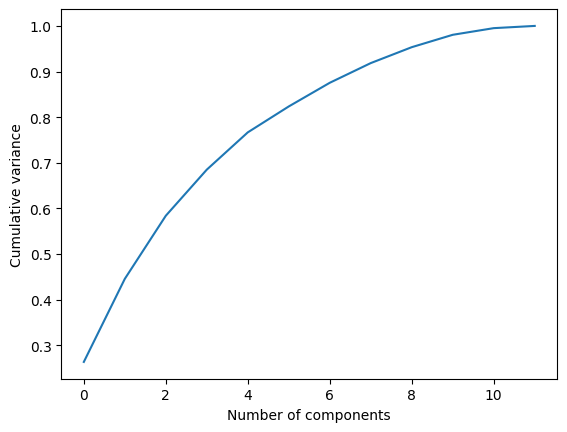

In [181]:
plt.plot(cum_cov)
plt.xlabel("Number of components")
plt.ylabel("Cumulative variance")
plt.show()

The cumulative variance should be over 90% so we decide to use

In [182]:
for index, value in enumerate(cum_cov):
    if value >= 0.9:
        p_c = index + 1
        break
print(p_c)

8


Principal Components as applied here:

In [183]:
def apply_pca(dataset, components):
    pca = PCA(n_components=components)
    X_PCA = pca.fit_transform(dataset)
    return X_PCA

X_PCA = apply_pca(X, p_c)
X_PCA

array([[-1.65210813, -1.34559765, -1.51717628, ..., -0.77964578,
        -0.44406881,  0.31804015],
       [-0.873317  , -2.30236875, -0.08220165, ...,  0.41819145,
         1.15061666,  0.52221309],
       [-0.80282321, -1.58680956, -0.78086476, ...,  0.22185649,
         0.42338918,  0.44022026],
       ...,
       [-2.19149891, -0.93395521,  0.75843576, ...,  0.32155878,
        -0.40693987,  0.03511812],
       [-2.14664736,  0.39856272,  2.22147239, ..., -0.95943017,
         0.43260776,  0.0142009 ],
       [-2.30953651, -1.00494922,  0.85242887, ..., -0.48399549,
        -0.66110191,  0.64552555]], shape=(1143, 8))

## Task 3 b)

Import needed libraries:

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

Perform modeling and test from task 1 c) based on Marias code

In [ ]:
# ---------- Features (X) and target (y) ----------
X = df.drop(columns=["quality"])     # 11 input attributes
y = df["quality"]                    # binary target (0 / 1)

# ---------- Pipeline: scaler followed by SVM ----------
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm",    SVC()),
])

# ---------- Hyperparameter grid (same as agreed with team) ----------
# Prefix "svm__" tells GridSearch that the parameter belongs to the
# "svm" step of the Pipeline.
param_grid = {
    "svm__kernel": ["linear", "rbf"],
    "svm__C":      [0.1, 1, 10, 100, 1000],
    "svm__gamma":  [1, 0.1, 0.01, 0.001, 0.0001],
}
# Total combinations: 2 * 5 * 5 = 50 per GridSearch call.

# ---------- 10 runs ----------
N_RUNS = 10
accuracies   = []   # test accuracy for every run
best_params  = []   # best hyperparameters for every run

print("Running 10 train/test runs with GridSearch (may take ~1 min)\n")

for run in range(N_RUNS):
    # Each run uses a different random_state so that train/test split
    # is different every time -> simulates "k-fold-like" repetition.
    # stratify=y keeps the class balance (621/522) in both train and
    # test, otherwise small splits could become unbalanced by chance.
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=run, stratify=y
    )

    # Apply pca for train and test set to reduce number of componenets
    X_train = apply_pca(X_train, p_c)
    X_test = apply_pca(X_test, p_c)

    # GridSearchCV with 5-fold cross validation on the training set.
    # scoring="accuracy" because classes are roughly balanced
    # (lecture: "Accuracy is a good measure if all classes are balanced").
    # n_jobs=-1 uses all CPU cores in parallel.
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=5,
        scoring="accuracy",
        n_jobs=-1,
    )
    grid.fit(X_train, y_train)

    # Evaluate the best estimator (with refit on the full train set,
    # which GridSearchCV does automatically by default) on the held-out
    # test set.
    test_acc = grid.score(X_test, y_test)

    accuracies.append(test_acc)
    best_params.append(grid.best_params_)

    print(f"Run {run + 1:2d}  accuracy = {test_acc:.4f}  "
          f"best params = {grid.best_params_}")

# ---------- Summary ----------
mean_acc = np.mean(accuracies)
std_acc  = np.std(accuracies)

print("\n" + "=" * 60)
print(f"Task 1c summary over {N_RUNS} runs")
print(f"  Mean accuracy: {mean_acc:.4f}")
print(f"  Std  accuracy: {std_acc:.4f}")
print("=" * 60)

Running 10 train/test runs with GridSearch (may take ~1 min)

Run  1  accuracy = 0.6987  best params = {'svm__C': 10, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}
Run  2  accuracy = 0.6769  best params = {'svm__C': 10, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}
Run  3  accuracy = 0.4236  best params = {'svm__C': 1, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}
Run  4  accuracy = 0.7031  best params = {'svm__C': 1, 'svm__gamma': 1, 'svm__kernel': 'rbf'}
Run  5  accuracy = 0.6900  best params = {'svm__C': 100, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Run  6  accuracy = 0.6594  best params = {'svm__C': 1000, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}
Run  7  accuracy = 0.6725  best params = {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Run  8  accuracy = 0.7555  best params = {'svm__C': 100, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Run  9  accuracy = 0.7686  best params = {'svm__C': 0.1, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}
Run 10  accuracy = 0.7031  best params = {'svm__C': 1000, '